In [12]:
# ============================================================
# CELL 1 — Setup, Load & Data Validation
# Project: Bangla Cyberbullying Detection & Social Engagement Prediction
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, re, glob, os
pd.set_option('display.max_colwidth', 80)

PROJECT_DIR = '/content/drive/MyDrive/cyberbullying-detection'
RAW_DIR     = f'{PROJECT_DIR}/data/raw'

csv_files = glob.glob(f'{RAW_DIR}/*.csv')
assert csv_files, f'No CSV found in {RAW_DIR}'
CSV_PATH = csv_files[0]
print(f'Loading: {os.path.basename(CSV_PATH)}\n')

df = pd.read_csv(CSV_PATH)

# ---------- 1. Structure ----------
print('='*60); print('1. STRUCTURE')
print(f'shape: {df.shape}')
print(df.dtypes.to_string())

# ---------- 2. Missing values ----------
print('\n'+'='*60); print('2. MISSING VALUES')
print(df.isna().sum().to_string())

# ---------- 3. Corrupted rows ----------
print('\n'+'='*60); print('3. CORRUPTED ROWS')
corrupt = df['Text'].astype(str).str.strip().isin(['#NAME?', '#REF!', '#VALUE!', ''])
print(f'Excel-error / empty Text: {corrupt.sum()}')

# ---------- 4. Duplicates ----------
print('\n'+'='*60); print('4. DUPLICATE ANALYSIS')
txt = df['Text'].astype(str).str.strip()
print(f'fully identical rows      : {df.duplicated().sum()}')
print(f'duplicated Text values    : {txt.duplicated().sum()}')

nlab = df.assign(_t=txt).groupby('_t')['Label'].nunique()
consistent_dup = df.assign(_t=txt)[df.assign(_t=txt)['_t'].isin(nlab[nlab == 1].index) & txt.duplicated(keep=False)]
conflicting    = nlab[nlab > 1].index
print(f'dup Text, SAME label      : {len(consistent_dup)} rows')
print(f'dup Text, CONFLICTING label: {len(conflicting)} unique texts '
      f'({df.assign(_t=txt)["_t"].isin(conflicting).sum()} rows)')
print('\n--- conflicting examples (strategy must be documented, do NOT drop silently) ---')
for t in list(conflicting)[:5]:
    print(f'  {t[:55]!r} -> {df.assign(_t=txt).query("_t == @t")["Label"].tolist()}')

# ---------- 5. Text length ----------
print('\n'+'='*60); print('5. TEXT LENGTH')
wc = txt.str.split().str.len()
print(f'chars  -> {df["Text"].astype(str).str.len().describe()[["mean","50%","max"]].round(1).to_dict()}')
print(f'words  -> {wc.describe()[["mean","50%","max"]].round(1).to_dict()}')
print(f'<=2 words: {(wc <= 2).sum()}   <=1 word: {(wc <= 1).sum()}')

# ---------- 6. Class balance ----------
print('\n'+'='*60); print('6. CLASS BALANCE (Objective 1 target)')
vc = df['Label'].value_counts()
print(pd.DataFrame({'count': vc, 'pct': (vc/len(df)*100).round(2)}).to_string())
print(f'imbalance ratio (max/min): {vc.max()/vc.min():.1f} : 1')

# ---------- 7. Reaction count ----------
print('\n'+'='*60); print('7. REACTION COUNT (Objective 2 target)')
y = df['Comment React Number']
print(f'zeros : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)   <=1 : {(y<=1).mean()*100:.1f}%   <=3 : {(y<=3).mean()*100:.1f}%')
print(f'unique values: {y.nunique()}   max: {y.max():.0f}')
print(y.quantile([.5,.75,.9,.95,.99,1.0]).to_string())

# ---------- 8. Metadata (EDA only — NOT model features) ----------
print('\n'+'='*60); print('8. METADATA (EDA only)')
print(f"Category: {df['Category'].value_counts().to_dict()}")
print(f"Gender  : {df['Gender'].value_counts().to_dict()}   <- check casing inconsistency")

# ---------- 9. Noise indicators ----------
print('\n'+'='*60); print('9. NOISE INDICATORS')
print(f"leading/trailing whitespace : {(df['Text'].astype(str) != txt).sum()}")
print(f"contains URL                : {txt.str.contains(r'http|www\\.').sum()}")
print(f"contains newline            : {txt.str.contains('\\n').sum()}")
print(f"rows with <50% Bangla chars : "
      f"{txt.map(lambda s: len(re.findall(r'[\u0980-\u09FF]', s)) / max(len(re.sub(r'\\s','',s)), 1) < 0.5).sum()}")

print('\n'+'='*60)
print('Validation complete. df loaded UNMODIFIED — cleaning in next cell.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading: Cyberbulling Bangla Dataset.csv

1. STRUCTURE
shape: (44001, 5)
Text                     object
Category                 object
Gender                   object
Comment React Number    float64
Label                    object

2. MISSING VALUES
Text                    0
Category                0
Gender                  0
Comment React Number    3
Label                   0

3. CORRUPTED ROWS
Excel-error / empty Text: 7

4. DUPLICATE ANALYSIS
fully identical rows      : 142
duplicated Text values    : 601
dup Text, SAME label      : 1008 rows
dup Text, CONFLICTING label: 48 unique texts (109 rows)

--- conflicting examples (strategy must be documented, do NOT drop silently) ---
  '#NAME?' -> ['Harassment', 'Harassment', 'Harassment', 'Harassment', 'Hate Speech', 'Neutral', 'Harassment']
  'অবশেষে মুক্তি পেল বিলাশবাড়ীর আবু রায়হান মামুর অভিনীত শর' -> ['Neu

In [13]:
# ============================================================
# CELL 2 — Cleaning & Documented Duplicate/Conflict Resolution
# Input : df (raw, unmodified from Cell 1)
# Output: df_clean + audit trail + archived conflict set
# ============================================================
import unicodedata, os

PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

audit = {'raw_rows': len(df)}
d = df.copy()

# ---- STEP 1: corrupted rows (Excel formula errors) ----
corrupt_mask = d['Text'].astype(str).str.strip().isin(['#NAME?', '#REF!', '#VALUE!', '', 'nan'])
audit['dropped_corrupted'] = int(corrupt_mask.sum())
d = d[~corrupt_mask].copy()

# ---- STEP 2: Unicode NFC + whitespace normalization ----
# Bangla conjuncts exist in composed/decomposed forms; without NFC
# identical-looking texts will not match during deduplication.
def normalize(s):
    s = unicodedata.normalize('NFC', str(s))
    s = s.replace('​', '').replace('‌', '').replace('‍', '')  # zero-width chars
    return re.sub(r'\s+', ' ', s).strip()

d['Text'] = d['Text'].map(normalize)
audit['rows_after_normalize'] = len(d)

# ---- STEP 3: metadata casing (EDA only, never a model feature) ----
d['Gender']   = d['Gender'].str.strip().str.capitalize()
d['Category'] = d['Category'].str.strip().str.capitalize()

# ---- STEP 4: missing reaction counts ----
audit['react_missing'] = int(d['Comment React Number'].isna().sum())
d['Comment React Number'] = d['Comment React Number'].fillna(0).astype(int)

# ---- STEP 5: CONFLICTING-LABEL RESOLUTION (documented, not silent) ----
nlab = d.groupby('Text')['Label'].nunique()
conflict_texts = set(nlab[nlab > 1].index)
audit['conflicting_texts'] = len(conflict_texts)
audit['conflicting_rows']  = int(d['Text'].isin(conflict_texts).sum())

# archive the FULL conflicting set before resolving anything
conflict_df = d[d['Text'].isin(conflict_texts)].sort_values('Text')
conflict_df.to_csv(f'{PROCESSED_DIR}/conflicting_labels.csv', index=False)

# strategy: majority vote; drop only on a tie (no annotation consensus)
resolved, tie_texts = {}, []
for t, grp in d[d['Text'].isin(conflict_texts)].groupby('Text'):
    vc = grp['Label'].value_counts()
    if len(vc) > 1 and vc.iloc[0] == vc.iloc[1]:
        tie_texts.append(t)
    else:
        resolved[t] = vc.index[0]

d['Label'] = d.apply(lambda r: resolved.get(r['Text'], r['Label']), axis=1)
rows_before_tie_drop = len(d)
d = d[~d['Text'].isin(tie_texts)].copy()

audit['conflicts_majority_resolved'] = len(resolved)
audit['conflicts_dropped_tie']       = len(tie_texts)
audit['rows_dropped_tie']            = rows_before_tie_drop - len(d)

# ---- STEP 6: duplicate Text removal (AFTER normalization, BEFORE split) ----
before = len(d)
d = d.drop_duplicates(subset='Text', keep='first').reset_index(drop=True)
audit['dropped_duplicate_text'] = before - len(d)

# ---- STEP 7: empty / very short ----
audit['empty_removed'] = int((d['Text'].str.len() == 0).sum())
d = d[d['Text'].str.len() > 0].reset_index(drop=True)
wc = d['Text'].str.split().str.len()
audit['kept_1word'] = int((wc <= 1).sum())   # KEPT: short slurs carry strong signal
audit['kept_2word'] = int((wc <= 2).sum())

# ---- STEP 8: save + report ----
df_clean = d
df_clean.to_csv(f'{PROCESSED_DIR}/cleaned.csv', index=False)
audit['final_rows']    = len(df_clean)
audit['total_removed'] = audit['raw_rows'] - audit['final_rows']

print('=' * 60); print('CLEANING AUDIT TRAIL')
for k, v in audit.items():
    print(f'  {k:32s}: {v}')

print('\n' + '=' * 60); print('TIE CASES DROPPED (no annotation consensus)')
for t in tie_texts[:10]:
    print(f'  {t[:60]!r}')
print(f'  ... total {len(tie_texts)}')

print('\n' + '=' * 60); print('CLASS BALANCE AFTER CLEANING')
vc = df_clean['Label'].value_counts()
print(pd.DataFrame({'count': vc, 'pct': (vc / len(df_clean) * 100).round(2)}).to_string())

print(f'\nSaved -> {PROCESSED_DIR}/cleaned.csv')
print(f'Saved -> {PROCESSED_DIR}/conflicting_labels.csv  (manual review / thesis appendix)')

CLEANING AUDIT TRAIL
  raw_rows                        : 44001
  dropped_corrupted               : 7
  rows_after_normalize            : 43994
  react_missing                   : 3
  conflicting_texts               : 52
  conflicting_rows                : 113
  conflicts_majority_resolved     : 5
  conflicts_dropped_tie           : 47
  rows_dropped_tie                : 94
  dropped_duplicate_text          : 755
  empty_removed                   : 0
  kept_1word                      : 1049
  kept_2word                      : 3785
  final_rows                      : 43145
  total_removed                   : 856

TIE CASES DROPPED (no annotation consensus)
  'অবশেষে মুক্তি পেল বিলাশবাড়ীর আবু রায়হান মামুর অভিনীত শর্ট '
  'অভিনেত্রী মানেই"সেচ্ছায় ধর্ষিতা" এবং "মর্ডান বেশ্যা" ! তারা'
  'অভিনেত্রী মানেইসেচ্ছায় "ধর্ষিতা" এবং মর্ডান "বেশ্যা" ! তারা'
  'অরে বাটপার'
  'অসভ্য মেয়ে'
  'আচোদা'
  'আমার ক্রাশ'
  'এর একাধিক যৌন সংগি আছে এ শয়তান মেয়ে তার বাবার সাথেও অপকর্ম'
  'ওরে বাড়া'
  'খাওয

Bangla font: NotoSansBengali-Bold.ttf


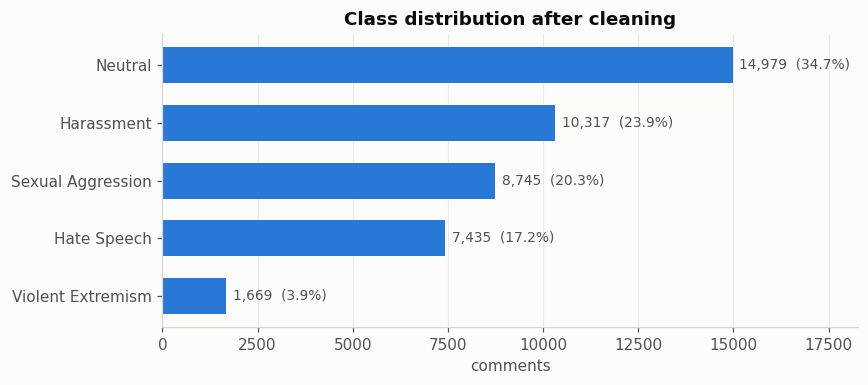

imbalance ratio  : 9.0 : 1
minority class   : Violent Extremism (1,669 samples)
-> use class_weight="balanced" (LogReg) and weighted loss (BanglaBERT); report macro-F1


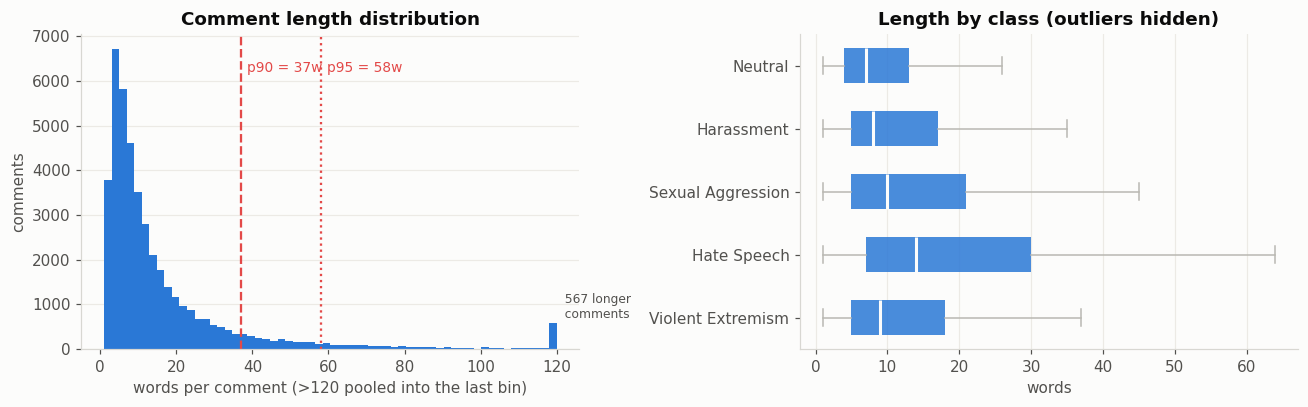

word-count percentiles:
0.50      9.0
0.75     18.0
0.90     37.0
0.95     58.0
0.99    136.0
1.00    210.0
-> BanglaBERT max_length: subword tokens run ~1.5-2x words for Bangla;
   p95 = 58 words -> start at max_length=128 (covers ~95.8% of comments at 64 words)


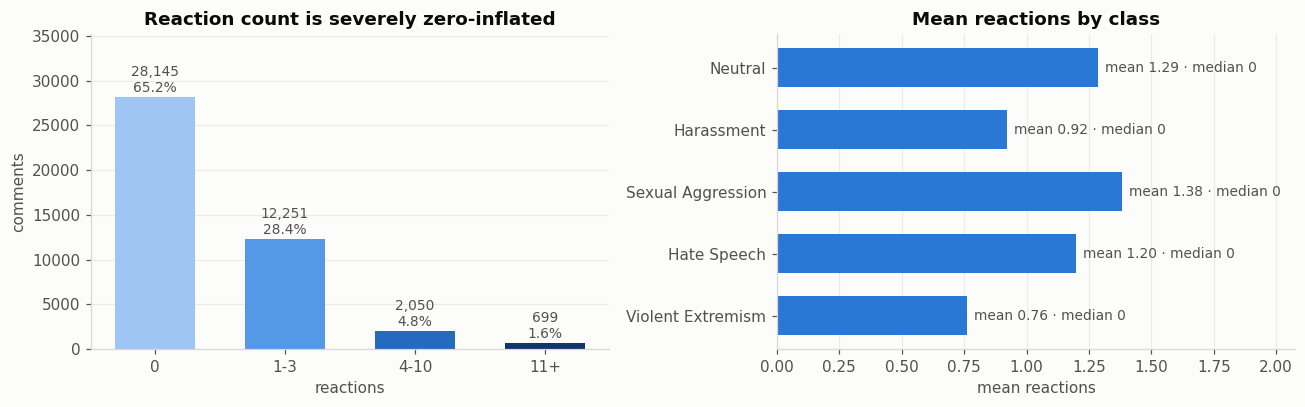

reaction tiers:
Comment React Number
0       65.23
1-3     28.39
4-10     4.75
11+      1.62

median reactions is 0 for EVERY class:
                    mean  median
Label                           
Neutral            1.286     0.0
Harassment         0.921     0.0
Sexual Aggression  1.384     0.0
Hate Speech        1.198     0.0
Violent Extremism  0.763     0.0


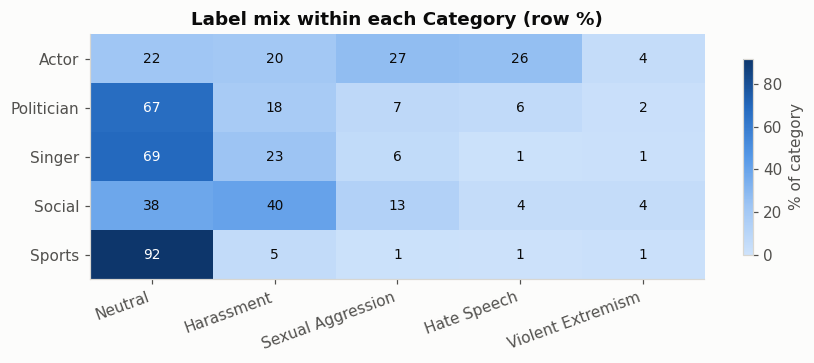

Category is NOT a model feature (context.md) — this documents why:
label mix differs sharply by category, so including it would leak target signal.

most distinctive tokens per class (log-odds vs rest):
  Neutral           : হুয়াওয়ে অভিরাম বিনম্র বঙ্গবন্ধু। সজীব ওয়াজেদ মোবারক। ফিতরের
  Harassment        : পাগলী পাগলে ছাগল। বান্দরের বাটপার ময়দা টোকাই ফাউল
  Sexual Aggression : খুইল্যা মাঙ্গির মাউড়া পো২০। পোলা৯। পো২৪.ভুদার পো২৬.লটির খাওয়ামু
  Hate Speech       : নাস্তিক্যবাদ মুনাফিকের একটিতেও নাস্তিক... ইহুদী মূলনীতির কাফিরকে পরিগণিত।
  Violent Extremism : জুতাপেটা জবাই পেটা জুতা বিতারিত ফাসি জুতার পিঠা


/tmp/ipykernel_2958/3676404317.py:176: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  plt.tight_layout(); plt.savefig(f'{FIG_DIR}/05_distinctive_tokens.png', bbox_inches='tight'); plt.show()
/tmp/ipykernel_2958/3676404317.py:176: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  plt.tight_layout(); plt.savefig(f'{FIG_DIR}/05_distinctive_tokens.png', bbox_inches='tight'); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Bengali.
  fig.canvas.print_figure(bytes_io, **kw)


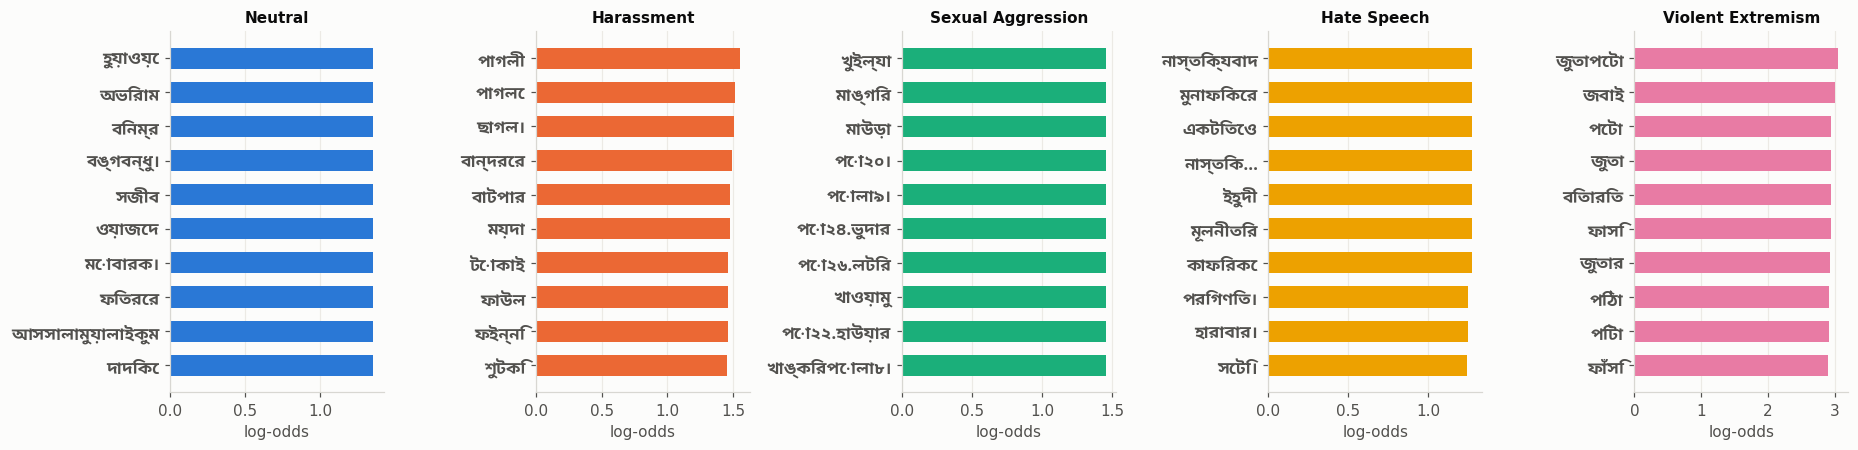


OBJECTIVE 2 — ENGAGEMENT SIGNAL DIAGNOSTIC
corr(word count, reactions)        : +0.0873
reactions explained by Label alone : eta^2 = 0.0008
zero-reaction share                : 65.2%
distinct target values             : 113

Tier framing (Option B) would give these classes:
Comment React Number
0       65.2
1-3     28.4
4-10     4.8
11+      1.6

Missing confounders (not in dataset): post reach, follower count,
timestamp, thread position — these drive reaction count, not text.

Figures saved -> /content/drive/MyDrive/cyberbullying-detection/reports/figures


In [14]:
# ============================================================
# CELL 3 — Exploratory Data Analysis
# Input : df_clean (or data/processed/cleaned.csv)
# Output: figures in reports/figures/ + decision evidence for Objective 2
# ============================================================
import matplotlib, os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

FIG_DIR = f'{PROJECT_DIR}/reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# reload if the runtime was restarted
try:
    df_clean
except NameError:
    df_clean = pd.read_csv(f'{PROJECT_DIR}/data/processed/cleaned.csv')

# ---- Bangla font (matplotlib renders Bangla as empty boxes without it) ----
os.system('apt-get -qq install -y fonts-noto-core > /dev/null 2>&1')
fm._load_fontmanager(try_read_cache=False)
bengali = [f for f in fm.findSystemFonts() if 'Bengali' in os.path.basename(f)]
BN_FONT = fm.FontProperties(fname=bengali[0]) if bengali else fm.FontProperties()
print('Bangla font:', os.path.basename(bengali[0]) if bengali else 'NOT FOUND — Bangla labels will be boxes')

# ---- design tokens ----
BLUE, INK, INK2, SURF = '#2a78d6', '#0b0b0b', '#52514e', '#fcfcfb'
CAT = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
SEQ = ['#cde2fb', '#9ec5f4', '#5598e7', '#256abf', '#0d366b']
plt.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF,
    'axes.edgecolor': '#d8d7d2', 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'xtick.color': INK2, 'ytick.color': INK2, 'text.color': INK,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#eceae5', 'grid.linewidth': 0.8,
    'font.size': 10, 'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'figure.dpi': 110,
})

ORDER = ['Neutral', 'Harassment', 'Sexual Aggression', 'Hate Speech', 'Violent Extremism']
d = df_clean
wc = d['Text'].str.split().str.len()
react = d['Comment React Number']

# ============================================================
# FIG 1 — Class distribution
# ============================================================
fig, ax = plt.subplots(figsize=(8, 3.6))
vc = d['Label'].value_counts().reindex(ORDER)
bars = ax.barh(range(len(vc)), vc.values, color=BLUE, height=0.62)
ax.set_yticks(range(len(vc))); ax.set_yticklabels(vc.index)
ax.invert_yaxis(); ax.set_xlabel('comments')
ax.set_title('Class distribution after cleaning')
ax.xaxis.grid(True); ax.set_axisbelow(True)
for i, v in enumerate(vc.values):
    ax.text(v + vc.max()*0.012, i, f'{v:,}  ({v/len(d)*100:.1f}%)',
            va='center', fontsize=9, color=INK2)
ax.set_xlim(0, vc.max()*1.22)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/01_class_distribution.png', bbox_inches='tight'); plt.show()

print(f'imbalance ratio  : {vc.max()/vc.min():.1f} : 1')
print(f'minority class   : {vc.idxmin()} ({vc.min():,} samples)')
print('-> use class_weight="balanced" (LogReg) and weighted loss (BanglaBERT); report macro-F1')

# ============================================================
# FIG 2 — Text length, overall + per class (drives BanglaBERT max_length)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

CLIP = 120
ax1.hist(wc.clip(upper=CLIP), bins=60, color=BLUE)
ax1.set_xlabel(f'words per comment (>{CLIP} pooled into the last bin)'); ax1.set_ylabel('comments')
ax1.set_title('Comment length distribution')
ax1.yaxis.grid(True); ax1.set_axisbelow(True)
for q, style in [(0.90, '--'), (0.95, ':')]:          # both inside the plotted range
    v = wc.quantile(q)
    ax1.axvline(v, color='#e34948', ls=style, lw=1.5)
    ax1.text(v + 1.5, ax1.get_ylim()[1]*0.88, f'p{int(q*100)} = {v:.0f}w', fontsize=9, color='#e34948')
ax1.text(CLIP, ax1.get_ylim()[1]*0.10, f'  {(wc > CLIP).sum():,} longer\n  comments', fontsize=8, color=INK2)

data = [wc[d['Label'] == c].values for c in ORDER]
bp = ax2.boxplot(data, vert=False, widths=0.55, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor(BLUE); patch.set_edgecolor('none'); patch.set_alpha(0.85)
for med in bp['medians']:
    med.set_color(SURF); med.set_linewidth(2)
for w in bp['whiskers'] + bp['caps']:
    w.set_color('#b9b8b2')
ax2.set_yticklabels(ORDER); ax2.invert_yaxis()
ax2.set_xlabel('words'); ax2.set_title('Length by class (outliers hidden)')
ax2.xaxis.grid(True); ax2.set_axisbelow(True)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/02_text_length.png', bbox_inches='tight'); plt.show()

print('word-count percentiles:')
print(wc.quantile([.5, .75, .9, .95, .99, 1.0]).round(0).to_string())
print(f'-> BanglaBERT max_length: subword tokens run ~1.5-2x words for Bangla;')
print(f'   p95 = {wc.quantile(.95):.0f} words -> start at max_length=128 '
      f'(covers ~{(wc <= 64).mean()*100:.1f}% of comments at 64 words)')

# ============================================================
# FIG 3 — Reaction count: the Objective 2 evidence
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

tiers = pd.cut(react, [-1, 0, 3, 10, 1e9], labels=['0', '1-3', '4-10', '11+'])
tc = tiers.value_counts().reindex(['0', '1-3', '4-10', '11+'])
ax1.bar(range(len(tc)), tc.values, color=SEQ[1:], width=0.62)
ax1.set_xticks(range(len(tc))); ax1.set_xticklabels(tc.index)
ax1.set_xlabel('reactions'); ax1.set_ylabel('comments')
ax1.set_title('Reaction count is severely zero-inflated')
ax1.yaxis.grid(True); ax1.set_axisbelow(True)
for i, v in enumerate(tc.values):
    ax1.text(i, v + tc.max()*0.02, f'{v:,}\n{v/len(d)*100:.1f}%',
             ha='center', fontsize=9, color=INK2)
ax1.set_ylim(0, tc.max()*1.25)

med = d.groupby('Label')['Comment React Number'].agg(['mean', 'median']).reindex(ORDER)
ax2.barh(range(len(med)), med['mean'].values, color=BLUE, height=0.62)
ax2.set_yticks(range(len(med))); ax2.set_yticklabels(ORDER); ax2.invert_yaxis()
ax2.set_xlabel('mean reactions'); ax2.set_title('Mean reactions by class')
ax2.xaxis.grid(True); ax2.set_axisbelow(True)
for i, (m, md) in enumerate(zip(med['mean'], med['median'])):
    ax2.text(m + med['mean'].max()*0.02, i, f'mean {m:.2f} · median {md:.0f}',
             va='center', fontsize=9, color=INK2)
ax2.set_xlim(0, med['mean'].max()*1.5)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/03_reaction_distribution.png', bbox_inches='tight'); plt.show()

print('reaction tiers:'); print((tc / len(d) * 100).round(2).to_string())
print(f"\nmedian reactions is {int(react.median())} for EVERY class:")
print(med.round(3).to_string())

# ============================================================
# FIG 4 — Category x Label (EDA only; documents the confound)
# ============================================================
ct = pd.crosstab(d['Category'], d['Label'], normalize='index')[ORDER] * 100
fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(ct.values, cmap=matplotlib.colors.LinearSegmentedColormap.from_list('b', SEQ),
               aspect='auto', vmin=0, vmax=ct.values.max())
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=20, ha='right')
ax.set_yticks(range(len(ct))); ax.set_yticklabels(ct.index)
ax.set_title('Label mix within each Category (row %)')
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=9,
                color='white' if v > ct.values.max()*0.55 else INK)
plt.colorbar(im, ax=ax, label='% of category', shrink=0.8)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/04_category_label.png', bbox_inches='tight'); plt.show()

print('Category is NOT a model feature (context.md) — this documents why:')
print('label mix differs sharply by category, so including it would leak target signal.')

# ============================================================
# FIG 5 — Most distinctive tokens per class (log-odds vs rest)
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer
cvz = CountVectorizer(min_df=15, max_features=30000, token_pattern=r'(?u)\S+')
X = cvz.fit_transform(d['Text'])
vocab = np.array(cvz.get_feature_names_out())
total = np.asarray(X.sum(axis=0)).ravel() + 1.0

fig, axes = plt.subplots(1, 5, figsize=(17, 4.2))
print('\nmost distinctive tokens per class (log-odds vs rest):')
for ax, cls, col in zip(axes, ORDER, CAT):
    mask = (d['Label'] == cls).values
    cnt = np.asarray(X[mask].sum(axis=0)).ravel() + 1.0
    lo = np.log((cnt / cnt.sum()) / (total / total.sum()))
    lo[cnt < 8] = -np.inf                      # ignore rare noise
    top = np.argsort(lo)[::-1][:10][::-1]
    ax.barh(range(10), lo[top], color=col, height=0.62)
    ax.set_yticks(range(10))
    ax.set_yticklabels(vocab[top], fontproperties=BN_FONT, fontsize=11)
    ax.set_title(cls, fontsize=10)
    ax.set_xlabel('log-odds'); ax.xaxis.grid(True); ax.set_axisbelow(True)
    print(f'  {cls:18s}: ' + ' '.join(vocab[top][::-1][:8]))
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/05_distinctive_tokens.png', bbox_inches='tight'); plt.show()

# ============================================================
# OBJECTIVE 2 DECISION EVIDENCE
# ============================================================
print('\n' + '=' * 60)
print('OBJECTIVE 2 — ENGAGEMENT SIGNAL DIAGNOSTIC')
print('=' * 60)
corr_len = np.corrcoef(wc, react)[0, 1]
print(f'corr(word count, reactions)        : {corr_len:+.4f}')
print(f'reactions explained by Label alone : '
      f'eta^2 = {1 - d.groupby("Label")["Comment React Number"].transform("mean").sub(react).pow(2).sum() / react.sub(react.mean()).pow(2).sum():.4f}')
print(f'zero-reaction share                : {(react == 0).mean()*100:.1f}%')
print(f'distinct target values             : {react.nunique()}')
print('\nTier framing (Option B) would give these classes:')
print((tc / len(d) * 100).round(1).to_string())
print('\nMissing confounders (not in dataset): post reach, follower count,')
print('timestamp, thread position — these drive reaction count, not text.')
print(f'\nFigures saved -> {FIG_DIR}')

In [15]:
# ============================================================
# CELL 4 — Near-Duplicate Removal (leakage prevention)
# Exact dedup in Cell 2 is not enough: copypasta comments survive it
# with slightly different prefixes and would land in BOTH train and test.
# Input : df_clean   Output: df_dedup + archived near-duplicate clusters
# ============================================================
!pip install -q datasketch

from datasketch import MinHash, MinHashLSH
import unicodedata, os

try:
    df_clean
except NameError:
    df_clean = pd.read_csv(f'{PROJECT_DIR}/data/processed/cleaned.csv')

PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
SHINGLE_K = 5      # character shingle size
THRESHOLD = 0.80   # Jaccard similarity above which two comments are "the same"
NUM_PERM  = 128
MIN_LEN   = 0      # skip near-dup check below this many Bangla chars (see note below)

# ---- fingerprint: Bangla letters only (drops punctuation, digits, emoji, latin) ----
def fingerprint(s):
    return ''.join(ch for ch in unicodedata.normalize('NFC', str(s))
                   if '\u0980' <= ch <= '\u09FF')

fps = df_clean['Text'].map(fingerprint)

def shingles(s, k=SHINGLE_K):
    if len(s) < k:
        return {s} if s else set()
    return {s[i:i+k] for i in range(len(s) - k + 1)}

# ---- build LSH index ----
print(f'building MinHash LSH  (k={SHINGLE_K}, threshold={THRESHOLD}, perms={NUM_PERM}) ...')
lsh, mhs = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM), {}
for i, fp in enumerate(fps):
    if len(fp) < max(MIN_LEN, SHINGLE_K):
        continue
    m = MinHash(num_perm=NUM_PERM)
    for s in shingles(fp):
        m.update(s.encode('utf8'))
    mhs[i] = m
    lsh.insert(i, m)
print(f'indexed {len(mhs):,} comments')

# ---- union-find over near-duplicate pairs ----
parent = {i: i for i in mhs}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[max(ra, rb)] = min(ra, rb)   # earliest index becomes cluster root

for i, m in mhs.items():
    for j in lsh.query(m):
        if j != i:
            union(i, j)

clusters = {}
for i in mhs:
    clusters.setdefault(find(i), []).append(i)
multi = {r: idxs for r, idxs in clusters.items() if len(idxs) > 1}

print(f'near-duplicate clusters : {len(multi):,}')
print(f'rows inside clusters    : {sum(len(v) for v in multi.values()):,}')

# ---- archive every cluster BEFORE removing anything ----
rows = []
for cid, (root, idxs) in enumerate(sorted(multi.items(), key=lambda kv: -len(kv[1]))):
    for i in sorted(idxs):
        r = df_clean.iloc[i]
        rows.append({'cluster_id': cid, 'cluster_size': len(idxs), 'row_index': i,
                     'kept': i == min(idxs), 'Label': r['Label'],
                     'Comment React Number': r['Comment React Number'], 'Text': r['Text']})
cluster_df = pd.DataFrame(rows)
cluster_df.to_csv(f'{PROCESSED_DIR}/near_duplicate_clusters.csv', index=False)

# ---- do near-duplicates agree on their label? ----
if len(cluster_df):
    agree = cluster_df.groupby('cluster_id')['Label'].nunique()
    print(f'clusters with ONE label : {(agree == 1).sum():,}  ({(agree == 1).mean()*100:.1f}%)')
    print(f'clusters with MIXED lbl : {(agree > 1).sum():,}  <- annotation inconsistency')

# ---- keep one representative per cluster ----
drop_idx = {i for idxs in multi.values() for i in idxs if i != min(idxs)}
df_dedup = df_clean.drop(index=sorted(drop_idx)).reset_index(drop=True)

print('\n' + '=' * 60); print('NEAR-DUPLICATE REMOVAL')
print(f'  rows in  : {len(df_clean):,}')
print(f'  removed  : {len(drop_idx):,}')
print(f'  rows out : {len(df_dedup):,}')

print('\nlargest clusters:')
for cid in range(min(5, cluster_df['cluster_id'].nunique() if len(cluster_df) else 0)):
    g = cluster_df[cluster_df['cluster_id'] == cid]
    print(f'  x{len(g):<3d} [{g["Label"].iloc[0]:18s}] {g["Text"].iloc[0][:70]!r}')

print('\n' + '=' * 60); print('CLASS BALANCE AFTER NEAR-DEDUP')
vc = df_dedup['Label'].value_counts()
print(pd.DataFrame({'count': vc, 'pct': (vc / len(df_dedup) * 100).round(2)}).to_string())

df_dedup.to_csv(f'{PROCESSED_DIR}/deduplicated.csv', index=False)
print(f'\nSaved -> {PROCESSED_DIR}/deduplicated.csv')
print(f'Saved -> {PROCESSED_DIR}/near_duplicate_clusters.csv  (audit / thesis appendix)')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.2/107.2 kB 5.0 MB/s eta 0:00:00
building MinHash LSH  (k=5, threshold=0.8, perms=128) ...
indexed 42,773 comments
near-duplicate clusters : 1,011
rows inside clusters    : 2,844
clusters with ONE label : 962  (95.2%)
clusters with MIXED lbl : 49  <- annotation inconsistency

NEAR-DUPLICATE REMOVAL
  rows in  : 43,145
  removed  : 1,833
  rows out : 41,312

largest clusters:
  x32  [Hate Speech       ] 'ফেসবুক হ্যাক করার দায়ে আল্লাহ এর কাছে বিচার দিলেন? আপনি তো পরকালেই বি'
  x26  [Neutral           ] 'মাশাআল্লাহ♥'
  x24  [Hate Speech       ] 'নাস্তিক'
  x21  [Neutral           ] 'আলহামদুলিল্লাহ।'
  x19  [Neutral           ] 'জয় বাংলা।জয় বঙ্গবন্ধু।'

CLASS BALANCE AFTER NEAR-DEDUP
                   count    pct
Label                          
Neutral            14057  34.03
Harassment         10073  24.38
Sexual Aggression   8448  20.45
Hate Speech         7103  17.19
Violent Extremism   1631   3.95

Saved -> /content/drive/MyDrive/cybe

In [16]:
# ============================================================
# CELL 5 — Conservative Preprocessing + Stratified Split
# Input : df_dedup   Output: train/val/test CSVs shared by BOTH models
# One split, saved to disk, so TF-IDF and BanglaBERT are compared on
# identical rows (context.md Objective 3).
# ============================================================
import re, json, unicodedata, os
from sklearn.model_selection import train_test_split

try:
    df_dedup
except NameError:
    df_dedup = pd.read_csv(f'{PROJECT_DIR}/data/processed/deduplicated.csv')

PROCESSED_DIR = f'{PROJECT_DIR}/data/processed'
SPLIT_DIR     = f'{PROJECT_DIR}/data/splits'
os.makedirs(SPLIT_DIR, exist_ok=True)

SEED      = 42
TEST_SIZE = 0.15
VAL_SIZE  = 0.15

d = df_dedup.copy()

# ------------------------------------------------------------
# 1. TWO text views from the SAME rows
# ------------------------------------------------------------
URL_RE   = re.compile(r'https?://\S+|www\.\S+')
PUNCT_RE = re.compile(r'([^\u0980-\u09FFa-zA-Z0-9\s])')   # anything not letter/digit/space
DIGIT_RE = re.compile(r'[0-9\u09E6-\u09EF]+')

# Placeholders are plain alphanumerics on purpose: an angle-bracket form like
# <URL> would itself be split apart by PUNCT_RE below into '< URL >'.
URL_TOK, NUM_TOK = ' urltoken ', ' numtoken '

# --- view A: for BanglaBERT — keep everything the tokenizer can use ---
# Only URLs go; punctuation, emoji and casing are signal the model reads.
def prep_bert(s):
    s = URL_RE.sub(URL_TOK, str(s))
    return re.sub(r'\s+', ' ', s).strip()

# --- view B: for TF-IDF — same text, but tokenizer-friendly ---
# Punctuation/emoji are SEPARATED into their own tokens rather than deleted
# (an emoji or a run of '!!!' is signal), and digits collapse to one token
# so that '১০০', '২০২৩', '৫' do not each take a vocabulary slot.
def prep_tfidf(s):
    s = URL_RE.sub(URL_TOK, str(s))
    s = s.replace('\ufe0f', '')          # emoji variation selector -> would split off as junk
    s = PUNCT_RE.sub(r' \1 ', s)
    s = DIGIT_RE.sub(NUM_TOK, s)
    return re.sub(r'\s+', ' ', s).strip()

d['text_bert']  = d['Text'].map(prep_bert)
d['text_tfidf'] = d['Text'].map(prep_tfidf)

# NOTE: Bangla stopwords are deliberately NOT removed. In Bangla the 2nd-person
# pronouns তুই / তোর / তোরে (informal-derogatory) vs আপনি / আপনার (formal) are one
# of the strongest politeness signals for harassment — and every standard Bangla
# stopword list contains them. Removing them would delete the signal.
print('sample preprocessing:')
for i in [0, 1, 2]:
    print(f'  raw   : {d["Text"].iloc[i][:70]}')
    print(f'  bert  : {d["text_bert"].iloc[i][:70]}')
    print(f'  tfidf : {d["text_tfidf"].iloc[i][:70]}\n')

# ------------------------------------------------------------
# 2. Label encoding (fixed order, saved for reuse)
# ------------------------------------------------------------
LABELS = ['Neutral', 'Harassment', 'Sexual Aggression', 'Hate Speech', 'Violent Extremism']
label2id = {l: i for i, l in enumerate(LABELS)}
d['label_id'] = d['Label'].map(label2id)
assert d['label_id'].notna().all(), 'unexpected label value'
d['label_id'] = d['label_id'].astype(int)

with open(f'{SPLIT_DIR}/label_map.json', 'w') as f:
    json.dump({'label2id': label2id, 'id2label': {v: k for k, v in label2id.items()}}, f, indent=2)

# ------------------------------------------------------------
# 3. Stratified 70 / 15 / 15 split
# ------------------------------------------------------------
train_df, temp_df = train_test_split(
    d, test_size=TEST_SIZE + VAL_SIZE, random_state=SEED, stratify=d['Label'])
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_SIZE / (TEST_SIZE + VAL_SIZE),
    random_state=SEED, stratify=temp_df['Label'])

for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    part.reset_index(drop=True).to_csv(f'{SPLIT_DIR}/{name}.csv', index=False)

# ------------------------------------------------------------
# 4. Leakage check — must pass before any model is trained
# ------------------------------------------------------------
tr, va, te = set(train_df['Text']), set(val_df['Text']), set(test_df['Text'])
overlaps = {'train-val': len(tr & va), 'train-test': len(tr & te), 'val-test': len(va & te)}
print('=' * 60); print('LEAKAGE CHECK (exact text overlap between splits)')
for k, v in overlaps.items():
    print(f'  {k:12s}: {v}')
assert sum(overlaps.values()) == 0, 'TEXT OVERLAP BETWEEN SPLITS — do not train on this'
print('  -> no overlap')

# ------------------------------------------------------------
# 5. Report
# ------------------------------------------------------------
print('\n' + '=' * 60); print('SPLIT SIZES')
total = len(d)
for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'  {name:6s}: {len(part):6,}  ({len(part)/total*100:.1f}%)')
print(f'  {"total":6s}: {total:6,}')

print('\n' + '=' * 60); print('CLASS DISTRIBUTION PER SPLIT (%)')
dist = pd.DataFrame({
    name: part['Label'].value_counts(normalize=True).reindex(LABELS) * 100
    for name, part in [('train', train_df), ('val', val_df), ('test', test_df)]
}).round(2)
dist['train_n'] = train_df['Label'].value_counts().reindex(LABELS)
print(dist.to_string())

print('\n' + '=' * 60); print('CLASS WEIGHTS (for imbalanced training)')
from sklearn.utils.class_weight import compute_class_weight
w = compute_class_weight('balanced', classes=np.arange(len(LABELS)),
                         y=train_df['label_id'].values)
for l, wi in zip(LABELS, w):
    print(f'  {l:20s}: {wi:.3f}')
np.save(f'{SPLIT_DIR}/class_weights.npy', w)

print(f'\nSaved -> {SPLIT_DIR}/train.csv | val.csv | test.csv')
print(f'Saved -> {SPLIT_DIR}/label_map.json | class_weights.npy')
print('\nBoth models must read these files — do not re-split anywhere else.')


sample preprocessing:
  raw   : আওয়ামী লীগ স্বৈরাচারী সরকার যতো দিন ক্ষমতায় থাকবে, ততো দিন এই রকম হত
  bert  : আওয়ামী লীগ স্বৈরাচারী সরকার যতো দিন ক্ষমতায় থাকবে, ততো দিন এই রকম হত
  tfidf : আওয়ামী লীগ স্বৈরাচারী সরকার যতো দিন ক্ষমতায় থাকবে , ততো দিন এই রকম হ

  raw   : ঘরে বসে শুট করতে কেমন লেগেছে? ক্যামেরাতে কে ছিলেন?
  bert  : ঘরে বসে শুট করতে কেমন লেগেছে? ক্যামেরাতে কে ছিলেন?
  tfidf : ঘরে বসে শুট করতে কেমন লেগেছে ? ক্যামেরাতে কে ছিলেন ?

  raw   : অরে বাবা, এই টা কোন পাগল????
  bert  : অরে বাবা, এই টা কোন পাগল????
  tfidf : অরে বাবা , এই টা কোন পাগল ? ? ? ?

LEAKAGE CHECK (exact text overlap between splits)
  train-val   : 0
  train-test  : 0
  val-test    : 0
  -> no overlap

SPLIT SIZES
  train : 28,918  (70.0%)
  val   :  6,197  (15.0%)
  test  :  6,197  (15.0%)
  total : 41,312

CLASS DISTRIBUTION PER SPLIT (%)
                   train    val   test  train_n
Label                                          
Neutral            34.03  34.03  34.02     9840
Harassment         

train=28,918  val=6,197  test=6,197

MODEL SELECTION ON VALIDATION
  word12     C=1.0  feats= 29,160  val macro-F1=0.4743  (11.0s)
  word12     C=4.0  feats= 29,160  val macro-F1=0.4612  (11.5s)
  char25     C=1.0  feats= 71,766  val macro-F1=0.8098  (20.4s)
  char25     C=4.0  feats= 71,766  val macro-F1=0.8046  (26.0s)
  word+char  C=1.0  feats=100,926  val macro-F1=0.7968  (26.6s)
  word+char  C=4.0  feats=100,926  val macro-F1=0.7940  (32.0s)

best: char25  C=1.0  (val macro-F1=0.8098)

FINAL RESULTS

TF-IDF(char25,C=1.0)+LogReg  [val]
  accuracy    : 0.8277
  macro-F1    : 0.8098   <- headline metric (imbalanced data)
  weighted-F1 : 0.8274
                   precision  recall     f1  support
Neutral                0.847   0.871  0.859     2109
Harassment             0.781   0.743  0.761     1511
Sexual Aggression      0.818   0.831  0.824     1267
Hate Speech            0.897   0.879  0.888     1065
Violent Extremism      0.696   0.739  0.717      245

TF-IDF(char25,C=1.0)+LogReg

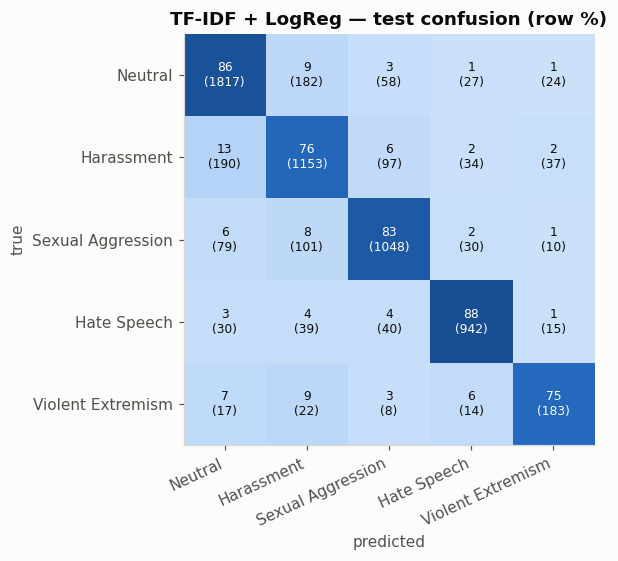


Saved -> /content/drive/MyDrive/cyberbullying-detection/reports/results/tfidf_metrics.json | tfidf_test_predictions.csv | tfidf_sweep.csv
Saved -> /content/drive/MyDrive/cyberbullying-detection/models/tfidf_logreg.joblib
Saved -> /content/drive/MyDrive/cyberbullying-detection/reports/figures/06_tfidf_confusion.png

BASELINE macro-F1 (test) = 0.8121  <- BanglaBERT must beat this


In [17]:
# ============================================================
# CELL 6 — TF-IDF + Logistic Regression  (context.md branch 1)
# Model selection on VAL, final numbers on TEST, predictions saved
# for error analysis. The evaluate() defined here is REUSED by the
# BanglaBERT cell so both models share one evaluation protocol.
# ============================================================
import json, os, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix)
import joblib

SPLIT_DIR  = f'{PROJECT_DIR}/data/splits'
MODEL_DIR  = f'{PROJECT_DIR}/models'
RESULT_DIR = f'{PROJECT_DIR}/reports/results'
FIG_DIR    = f'{PROJECT_DIR}/reports/figures'
for p in (MODEL_DIR, RESULT_DIR, FIG_DIR):
    os.makedirs(p, exist_ok=True)

train = pd.read_csv(f'{SPLIT_DIR}/train.csv')
val   = pd.read_csv(f'{SPLIT_DIR}/val.csv')
test  = pd.read_csv(f'{SPLIT_DIR}/test.csv')
LABELS = json.load(open(f'{SPLIT_DIR}/label_map.json'))['label2id']
LABELS = [l for l, _ in sorted(LABELS.items(), key=lambda kv: kv[1])]
SEED = 42
print(f'train={len(train):,}  val={len(val):,}  test={len(test):,}')

# ------------------------------------------------------------
# Shared evaluation protocol — BanglaBERT must call this same function
# ------------------------------------------------------------
def evaluate(y_true, y_pred, name, split):
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, average='macro')
    wf1 = f1_score(y_true, y_pred, average='weighted')
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred,
                                                 labels=range(len(LABELS)), zero_division=0)
    per_class = pd.DataFrame({'precision': p, 'recall': r, 'f1': f, 'support': s}, index=LABELS)
    return {'model': name, 'split': split, 'accuracy': acc,
            'macro_f1': mf1, 'weighted_f1': wf1,
            'per_class': per_class.round(4).to_dict('index')}, per_class

def show(res, per_class):
    print(f"\n{res['model']}  [{res['split']}]")
    print(f"  accuracy    : {res['accuracy']:.4f}")
    print(f"  macro-F1    : {res['macro_f1']:.4f}   <- headline metric (imbalanced data)")
    print(f"  weighted-F1 : {res['weighted_f1']:.4f}")
    print(per_class.round(3).to_string())

# ------------------------------------------------------------
# 1. Configs — the baseline is tuned on VAL so the comparison is fair.
#    An untuned baseline would make BanglaBERT look better than it is.
# ------------------------------------------------------------
def make_vec(kind):
    if kind == 'word12':
        return TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                               min_df=2, max_features=200_000, sublinear_tf=True)
    if kind == 'char25':
        return TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                               min_df=3, max_features=300_000, sublinear_tf=True)
    if kind == 'word+char':
        return FeatureUnion([('w', make_vec('word12')), ('c', make_vec('char25'))])
    raise ValueError(kind)

CONFIGS = [(k, C) for k in ('word12', 'char25', 'word+char') for C in (1.0, 4.0)]

Xtr_txt, ytr = train['text_tfidf'].astype(str), train['label_id'].values
Xva_txt, yva = val['text_tfidf'].astype(str),   val['label_id'].values
Xte_txt, yte = test['text_tfidf'].astype(str),  test['label_id'].values

print('\n' + '=' * 60); print('MODEL SELECTION ON VALIDATION')
rows, best = [], None
for kind, C in CONFIGS:
    t0 = time.time()
    vec = make_vec(kind)
    Xtr = vec.fit_transform(Xtr_txt)
    Xva = vec.transform(Xva_txt)
    clf = LogisticRegression(C=C, max_iter=2000, class_weight='balanced',
                             random_state=SEED, n_jobs=-1)
    clf.fit(Xtr, ytr)
    mf1 = f1_score(yva, clf.predict(Xva), average='macro')
    rows.append({'features': kind, 'C': C, 'n_features': Xtr.shape[1],
                 'val_macro_f1': round(mf1, 4), 'sec': round(time.time() - t0, 1)})
    print(f'  {kind:10s} C={C:<4} feats={Xtr.shape[1]:>7,}  val macro-F1={mf1:.4f}  ({rows[-1]["sec"]}s)')
    if best is None or mf1 > best[0]:
        best = (mf1, kind, C, vec, clf)

sweep = pd.DataFrame(rows).sort_values('val_macro_f1', ascending=False)
sweep.to_csv(f'{RESULT_DIR}/tfidf_sweep.csv', index=False)
best_f1, best_kind, best_C, vec, clf = best
print(f'\nbest: {best_kind}  C={best_C}  (val macro-F1={best_f1:.4f})')

# ------------------------------------------------------------
# 2. Final evaluation on TEST with the selected config
# ------------------------------------------------------------
Xte = vec.transform(Xte_txt)
pred_te = clf.predict(Xte)
res_te, pc_te = evaluate(yte, pred_te, f'TF-IDF({best_kind},C={best_C})+LogReg', 'test')
res_va, pc_va = evaluate(yva, clf.predict(vec.transform(Xva_txt)),
                         f'TF-IDF({best_kind},C={best_C})+LogReg', 'val')
print('\n' + '=' * 60); print('FINAL RESULTS')
show(res_va, pc_va)
show(res_te, pc_te)

# ------------------------------------------------------------
# 3. Confusion matrix
# ------------------------------------------------------------
cm  = confusion_matrix(yte, pred_te, labels=range(len(LABELS)))
cmn = cm / cm.sum(axis=1, keepdims=True) * 100
SEQ = ['#cde2fb', '#9ec5f4', '#5598e7', '#256abf', '#0d366b']
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(cmn, cmap=mcolors.LinearSegmentedColormap.from_list('b', SEQ), vmin=0, vmax=100)
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('TF-IDF + LogReg — test confusion (row %)', fontweight='bold')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{cmn[i,j]:.0f}\n({cm[i,j]})', ha='center', va='center', fontsize=8,
                color='white' if cmn[i, j] > 55 else '#0b0b0b')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/06_tfidf_confusion.png', bbox_inches='tight'); plt.show()

# ------------------------------------------------------------
# 4. Persist everything the comparison + error-analysis cells need
# ------------------------------------------------------------
out = test[['Text', 'text_tfidf', 'Label', 'label_id']].copy()
out['pred_id']    = pred_te
out['pred_label'] = [LABELS[i] for i in pred_te]
out['correct']    = out['label_id'] == out['pred_id']
out['confidence'] = clf.predict_proba(Xte).max(axis=1)
out.to_csv(f'{RESULT_DIR}/tfidf_test_predictions.csv', index=False)

json.dump({'val': res_va, 'test': res_te,
           'best_config': {'features': best_kind, 'C': best_C}},
          open(f'{RESULT_DIR}/tfidf_metrics.json', 'w'), indent=2, default=str)
joblib.dump({'vectorizer': vec, 'model': clf}, f'{MODEL_DIR}/tfidf_logreg.joblib')

print(f'\nSaved -> {RESULT_DIR}/tfidf_metrics.json | tfidf_test_predictions.csv | tfidf_sweep.csv')
print(f'Saved -> {MODEL_DIR}/tfidf_logreg.joblib')
print(f'Saved -> {FIG_DIR}/06_tfidf_confusion.png')
print(f'\nBASELINE macro-F1 (test) = {res_te["macro_f1"]:.4f}  <- BanglaBERT must beat this')


In [18]:
# ============================================================
# CELL 6.5 — Leakage sanity check on the 0.81 baseline
# Does each test comment have a near-twin sitting in train?
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

v = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3,
                    max_features=300_000, sublinear_tf=True)
A = v.fit_transform(train['text_tfidf'].astype(str))     # train
B = v.transform(test['text_tfidf'].astype(str))          # test
A = A.multiply(1 / (np.sqrt(A.multiply(A).sum(1)) + 1e-9))   # L2 normalise
B = B.multiply(1 / (np.sqrt(B.multiply(B).sum(1)) + 1e-9))
A, B = A.tocsr(), B.tocsr()

best_sim = np.zeros(B.shape[0])
for i in range(0, B.shape[0], 500):                      # chunked, memory-safe
    best_sim[i:i+500] = np.asarray((B[i:i+500] @ A.T).max(axis=1).todense()).ravel()

print('max char-TFIDF cosine similarity of each TEST doc to its closest TRAIN doc')
for t in (0.95, 0.90, 0.80, 0.70):
    print(f'  >= {t:.2f} : {(best_sim >= t).sum():5d}  ({(best_sim >= t).mean()*100:5.2f}% of test)')
print(f'  median  : {np.median(best_sim):.3f}')

# accuracy on the "has a near-twin in train" subset vs the rest
pred = pd.read_csv(f'{RESULT_DIR}/tfidf_test_predictions.csv')
for t in (0.90, 0.80):
    m = best_sim >= t
    if m.sum():
        print(f'\nthreshold {t}: accuracy on twinned={pred["correct"][m].mean():.4f} '
              f'(n={m.sum()})  vs clean={pred["correct"][~m].mean():.4f} (n={(~m).sum()})')


max char-TFIDF cosine similarity of each TEST doc to its closest TRAIN doc
  >= 0.95 :    66  ( 1.07% of test)
  >= 0.90 :   170  ( 2.74% of test)
  >= 0.80 :   477  ( 7.70% of test)
  >= 0.70 :   998  (16.10% of test)
  median  : 0.462

threshold 0.9: accuracy on twinned=0.9588 (n=170)  vs clean=0.8263 (n=6027)

threshold 0.8: accuracy on twinned=0.9455 (n=477)  vs clean=0.8203 (n=5720)


In [19]:
np.save(f'{RESULT_DIR}/test_train_similarity.npy', best_sim)

# clean-subset macro-F1 (eitai thesis e second number hishebe jabe)
from sklearn.metrics import f1_score
clean = best_sim < 0.80
print(f'TF-IDF  full  macro-F1 : {f1_score(pred["label_id"], pred["pred_id"], average="macro"):.4f}')
print(f'TF-IDF  clean macro-F1 : {f1_score(pred["label_id"][clean], pred["pred_id"][clean], average="macro"):.4f}  (n={clean.sum():,})')


TF-IDF  full  macro-F1 : 0.8121
TF-IDF  clean macro-F1 : 0.8019  (n=5,720)


In [ ]:
# ============================================================
# CELL 7 — BanglaBERT Fine-Tuning  (context.md branch 2)
# Same splits, same evaluate() as Cell 6. Manual training loop on
# purpose: the HF Trainer API keeps renaming arguments between
# versions, and this stays readable for the write-up.
# Needs GPU: Runtime -> Change runtime type -> T4 GPU
# ============================================================
!pip install -q transformers
!pip install -q git+https://github.com/csebuetnlp/normalizer

import json, os, time, numpy as np, pandas as pd, torch
import torch.nn as nn
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, confusion_matrix

# evaluate() must come from Cell 6 — one definition, one protocol (context.md Obj. 3)
try:
    evaluate
except NameError:
    raise RuntimeError('Run Cell 6 first: it defines the shared evaluate() protocol.')

MODEL_NAME = 'csebuetnlp/banglabert'
MAX_LEN    = 128        # Cell 3: p95 = 58 words, subwords run ~1.5-2x
BATCH      = 32
EPOCHS     = 3
LR         = 2e-5
SEED       = 42

torch.manual_seed(SEED); np.random.seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
assert device == 'cuda', 'No GPU. Runtime -> Change runtime type -> T4 GPU'
print('device:', torch.cuda.get_device_name(0))

# ---- BanglaBERT ships its own text normalizer; the model card requires it ----
try:
    from normalizer import normalize as bn_normalize
    print('csebuetnlp normalizer: OK')
except Exception as e:
    print(f'WARNING — normalizer unavailable ({e}); using raw text. '
          f'Model-card preprocessing not applied, expect slightly lower scores.')
    bn_normalize = lambda s: s

# ------------------------------------------------------------
# 1. Data
# ------------------------------------------------------------
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

class CommentDS(Dataset):
    def __init__(self, df):
        self.texts  = [bn_normalize(str(t)) for t in df['text_bert']]
        self.labels = df['label_id'].values
    def __len__(self):  return len(self.labels)
    def __getitem__(self, i):
        enc = tok(self.texts[i], truncation=True, max_length=MAX_LEN,
                  padding='max_length', return_tensors='pt')
        return {'input_ids': enc['input_ids'][0],
                'attention_mask': enc['attention_mask'][0],
                'labels': torch.tensor(self.labels[i], dtype=torch.long)}

dl_train = DataLoader(CommentDS(train), batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
dl_val   = DataLoader(CommentDS(val),   batch_size=BATCH*2, shuffle=False, num_workers=2)
dl_test  = DataLoader(CommentDS(test),  batch_size=BATCH*2, shuffle=False, num_workers=2)

# subword length check — confirms MAX_LEN was chosen sensibly
lens = [len(tok(bn_normalize(str(t)))['input_ids']) for t in train['text_bert'].head(3000)]
print(f'subword length (3k sample): p50={np.percentile(lens,50):.0f} '
      f'p95={np.percentile(lens,95):.0f} p99={np.percentile(lens,99):.0f} '
      f'| truncated at {MAX_LEN}: {np.mean(np.array(lens) > MAX_LEN)*100:.1f}%')

# ------------------------------------------------------------
# 2. Model + weighted loss (VE weight 5.06 from Cell 5)
# ------------------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(LABELS)).to(device)

cw = torch.tensor(np.load(f'{SPLIT_DIR}/class_weights.npy'), dtype=torch.float).to(device)
loss_fn = nn.CrossEntropyLoss(weight=cw)
print('class weights:', {l: round(float(w), 3) for l, w in zip(LABELS, cw)})

opt    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
steps  = len(dl_train) * EPOCHS
sched  = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
scaler = torch.amp.GradScaler('cuda')

@torch.no_grad()
def predict(dl):
    model.eval()
    preds, trues = [], []
    for b in dl:
        ids, am = b['input_ids'].to(device), b['attention_mask'].to(device)
        with torch.amp.autocast('cuda'):
            logits = model(input_ids=ids, attention_mask=am).logits
        preds.append(logits.float().argmax(-1).cpu()); trues.append(b['labels'])
    return torch.cat(preds).numpy(), torch.cat(trues).numpy()

# ------------------------------------------------------------
# 3. Train — keep the epoch with the best VAL macro-F1
# ------------------------------------------------------------
best_f1, best_state, history = -1, None, []
for ep in range(1, EPOCHS + 1):
    model.train(); t0, running = time.time(), 0.0
    for step, b in enumerate(dl_train, 1):
        ids, am, y = (b['input_ids'].to(device), b['attention_mask'].to(device),
                      b['labels'].to(device))
        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            logits = model(input_ids=ids, attention_mask=am).logits
            loss = loss_fn(logits.float(), y)
        scaler.scale(loss).backward()
        scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update(); sched.step()
        running += loss.item()
        if step % 200 == 0:
            print(f'  ep{ep} step {step}/{len(dl_train)}  loss={running/step:.4f}')

    pv, tv = predict(dl_val)
    vf1 = f1_score(tv, pv, average='macro')
    history.append({'epoch': ep, 'train_loss': running/len(dl_train),
                    'val_macro_f1': round(vf1, 4), 'sec': round(time.time()-t0, 1)})
    print(f'epoch {ep}: train_loss={running/len(dl_train):.4f}  '
          f'val macro-F1={vf1:.4f}  ({history[-1]["sec"]}s)')
    if vf1 > best_f1:
        best_f1 = vf1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print('   -> new best')

model.load_state_dict(best_state)
print(f'\nbest val macro-F1 = {best_f1:.4f}')

# ------------------------------------------------------------
# 4. Test evaluation — identical protocol to Cell 6
# ------------------------------------------------------------
pt, tt = predict(dl_test)
pv, tv = predict(dl_val)
res_te, pc_te = evaluate(tt, pt, 'BanglaBERT', 'test')
res_va, pc_va = evaluate(tv, pv, 'BanglaBERT', 'val')
print('\n' + '=' * 60); print('FINAL RESULTS')
show(res_va, pc_va); show(res_te, pc_te)

# clean-subset number, same as the TF-IDF sanity check
sim_path = f'{RESULT_DIR}/test_train_similarity.npy'
if os.path.exists(sim_path):
    clean = np.load(sim_path) < 0.80
    print(f'\nclean-subset macro-F1 (sim<0.80, n={clean.sum():,}): '
          f'{f1_score(tt[clean], pt[clean], average="macro"):.4f}')

# ------------------------------------------------------------
# 5. Confusion matrix + artifacts
# ------------------------------------------------------------
cm  = confusion_matrix(tt, pt, labels=range(len(LABELS)))
cmn = cm / cm.sum(axis=1, keepdims=True) * 100
SEQ = ['#cde2fb', '#9ec5f4', '#5598e7', '#256abf', '#0d366b']
fig, ax = plt.subplots(figsize=(6.4, 5.2))
ax.imshow(cmn, cmap=mcolors.LinearSegmentedColormap.from_list('b', SEQ), vmin=0, vmax=100)
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=25, ha='right')
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
ax.set_title('BanglaBERT — test confusion (row %)', fontweight='bold')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, f'{cmn[i,j]:.0f}\n({cm[i,j]})', ha='center', va='center', fontsize=8,
                color='white' if cmn[i, j] > 55 else '#0b0b0b')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/07_banglabert_confusion.png', bbox_inches='tight'); plt.show()

out = test[['Text', 'text_bert', 'Label', 'label_id']].copy()
out['pred_id']    = pt
out['pred_label'] = [LABELS[i] for i in pt]
out['correct']    = out['label_id'] == out['pred_id']
out.to_csv(f'{RESULT_DIR}/banglabert_test_predictions.csv', index=False)

json.dump({'val': res_va, 'test': res_te, 'history': history,
           'config': {'model': MODEL_NAME, 'max_len': MAX_LEN, 'batch': BATCH,
                      'epochs': EPOCHS, 'lr': LR, 'best_val_macro_f1': best_f1}},
          open(f'{RESULT_DIR}/banglabert_metrics.json', 'w'), indent=2, default=str)
model.save_pretrained(f'{MODEL_DIR}/banglabert'); tok.save_pretrained(f'{MODEL_DIR}/banglabert')

tfidf_f1 = json.load(open(f'{RESULT_DIR}/tfidf_metrics.json'))['test']['macro_f1']
print(f'\n{"=" * 60}')
print(f'TF-IDF + LogReg  test macro-F1 : {tfidf_f1:.4f}')
print(f'BanglaBERT       test macro-F1 : {res_te["macro_f1"]:.4f}')
print(f'delta                          : {res_te["macro_f1"] - tfidf_f1:+.4f}')
